# Notebook pour charger et afficher les représentations latentes

In [1]:
# Importation des librairies

import torch
import torch.utils.data as torchdata
import torchsummary
import neural_data as nd
import merlDB.database as db
import argparse
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import mae_model_brdf

c:\Users\33768\Desktop\TP N7\S9\BE_MERL\BE_MERL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Si c'est vide ça veut dire qu'on fait l'entraînement sur tous les matériaux, sinon remplacer par un matériaux
materiaux= ""

# Pourcentage de triplets (R,G,B) masqués (recommandé 0.5)
ratio_masking = 0.5

# Quantité de données à utiliser pour l'entraînement (min 1 max 100)
train_size = 100

# Batch size
batch_size = 20

# Epochs
epochs = 200

# poids ajouté (valeur par défaut = 1)
poids = 2 

# taille de l'espace latent (valeur par défaut = 768, il faut que ce soit divisible par le nombre de tête d'attention (par défaut 12))
embed_dim = 768

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# Récupération du dataset


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device", device)

parser = argparse.ArgumentParser()
parser.add_argument('--outdir', default='results/')
parser.add_argument('--merldir', default='merlDB/db/brdfs/')
parser.add_argument('--mediandir', default='merlDB/db/')
parser.add_argument('--batch_size', default=batch_size)
parser.add_argument('--train_size', default=train_size)
parser.add_argument('--monomat', default=None)
parser.add_argument('--epochs', default=epochs)
parser.add_argument('--lr', default=1e-4)
parser.add_argument('--load_previous', default=False)
parser.add_argument('--materiau', default=materiaux) 
args, unknown = parser.parse_known_args()


medians = db.readbin(args.mediandir + 'merl_median.binary')

def median_mapping(albedos, epsilon=0.002):
    return np.log((albedos + epsilon)/(medians + epsilon) + 1)
    
dbuilder = db.DBuilder(db_path=args.merldir, albedo_mapping=median_mapping)
#test_dbuilder = db.DBuilder(db_path=args.merldir, albedo_mapping=median_mapping)
ldb = dbuilder.list_db()
#print(ldb)
if args.load_previous:
    print('LOADING MODEL')
    train_info = np.load(args.outdir + 'train_info.npy', allow_pickle=True).item()
    mats = train_info.get('train_mats')
else:
    if args.materiau != "" :
        mats = [args.materiau]
        #test_mats = [args.materiau]
    else :
        mats_idx = np.random.choice(range(len(ldb)), int(args.train_size), replace=False)
        mats = [ldb[idx] for idx in mats_idx]
        #test_mats = [mat for mat in ldb if mat not in mats]

if not args.monomat is None:
    print("problème")
    mats = [args.monomat]

#print(mats)
for mat in tqdm(mats, 'Loading mats'):
    if mat != "Rea" :
        dbuilder.load_mat(mat)

"""
if torch.cuda.is_available():
    for mat in tqdm(test_mats, 'Loading test mats'):
        if mat != "Rea" :
            test_dbuilder.load_mat(mat)
            #dbuilder.load_mat(mat)
"""
dataset = nd.DBridge(dbuilder, device)
#test_dataset = nd.DBridge(test_dbuilder, device)
del dbuilder
#del test_dbuilder

Using device cuda


Loading mats:   0%|          | 0/100 [00:00<?, ?it/s]

merlDB/db/brdfs/silver-paint.binary
merlDB/db/brdfs/aluminium.binary


Loading mats:   2%|▏         | 2/100 [00:00<00:08, 12.02it/s]

merlDB/db/brdfs/pink-fabric.binary


...

merlDB/db/brdfs/specular-maroon-phenolic.binary
merlDB/db/brdfs/yellow-matte-plastic.binary


Loading mats:  99%|█████████▉| 99/100 [00:09<00:00, 10.09it/s]

merlDB/db/brdfs/gold-paint.binary
merlDB/db/brdfs/dark-red-paint.binary


Loading mats: 100%|██████████| 100/100 [00:09<00:00, 10.52it/s]


merlDB/db/brdfs/blue-metallic-paint.binary


## Sauvegarde des représentations latentes et des noms associés

-> nécessite de charger les poids d'un modèle déjà entraîné

In [7]:
# 1. Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mae = mae_model_brdf.MaskedAutoencoderViT3D(poids=poids, embed_dim=embed_dim)
mae.load_state_dict(torch.load("./results/mae.pt"))
mae.to(device)
mae.eval()

# 2. Use lists instead of pre-allocated tensors
# This avoids shape mismatch errors (e.g. 109 vs 433 tokens)
list_latents = []
list_names = []

print("Extracting features...")
# Using a DataLoader handles batching automatically
loader = torchdata.DataLoader(dataset, batch_size=1, shuffle=False)

for data in tqdm(loader):
    # Extract data
    X = data['values'].to(device)
    
    # DataLoader wraps strings in a tuple, extend flattens them into the list
    list_names.extend(data['mat'])

    with torch.no_grad():
        # Output shape: (Batch, Num_Tokens, 768)
        latent = mae.forward_features(X)
        
        # Move to CPU immediately to save GPU memory
        list_latents.append(latent.cpu())

# 3. Concatenate and Save
# Stack all latents into one big tensor: (Total_Samples, Num_Tokens, Embed_Dim)
representations_latentes = torch.cat(list_latents, dim=0)

print(f"Final Tensor Shape: {representations_latentes.shape}")

# Save the tensor
torch.save(representations_latentes, "./results/representations_latentes.pt")

# Save the list of strings directly
torch.save(list_names, "./results/noms_refs_representations_latentes.pt")

Extracting features...


100%|██████████| 100/100 [00:03<00:00, 30.35it/s]


Final Tensor Shape: torch.Size([100, 433, 768])


## Visualisation 2D

### T-SNE optimisé

In [ ]:
# Paramètres du t-SNE
perplexity_val = 10      
n_iter_val = 5000        
early_exag_val = 20      
metric_val = 'cosine'


Loading data...
Global representations shape: (100, 768)
Calcul du t-SNE optimisé...


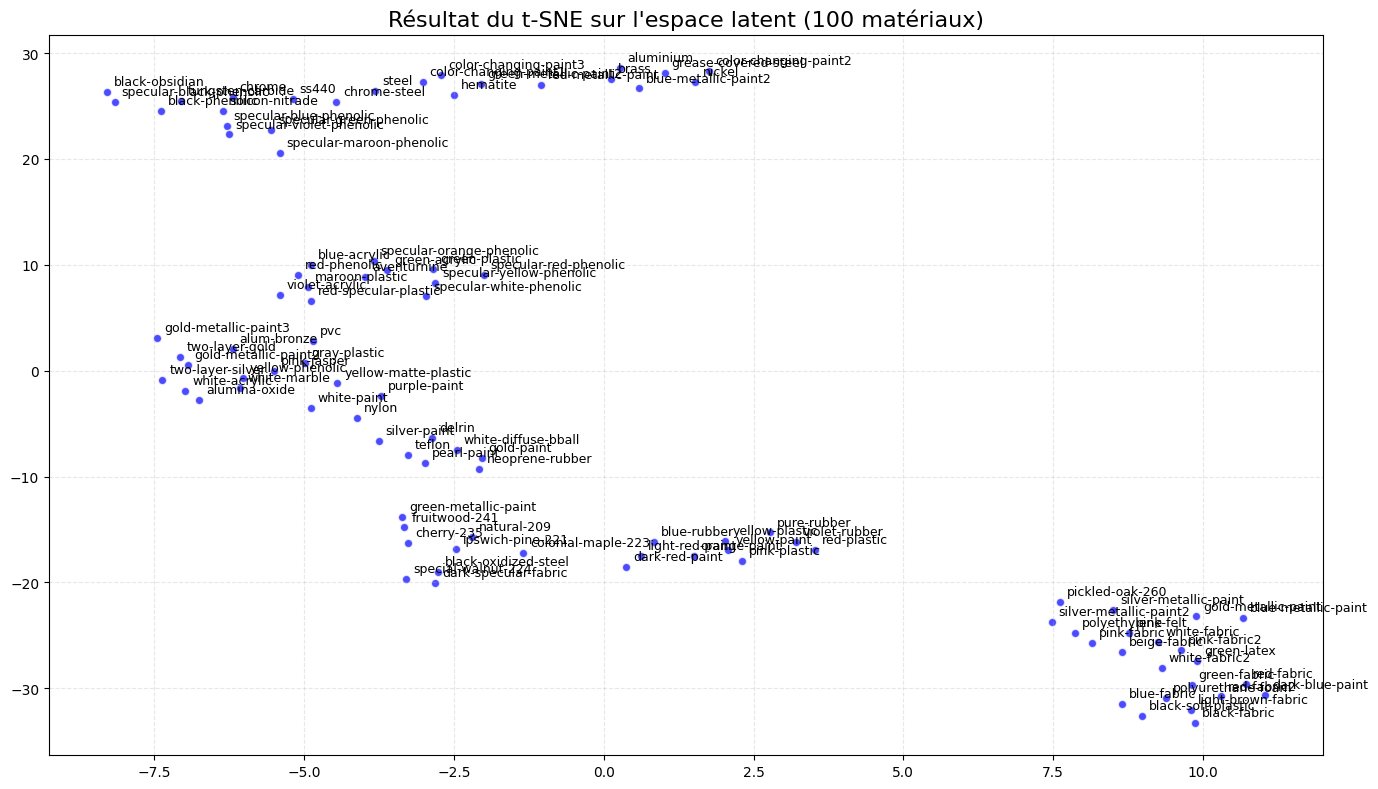

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


latents = torch.load("./results/representations_latentes.pt", map_location='cpu')

names = torch.load("./results/noms_refs_representations_latentes.pt")


assert len(latents) == len(names), f"Mismatch: {len(latents)} latents vs {len(names)} names"

global_reps = latents[:, 0, :].numpy()

print(f"Global representations shape: {global_reps.shape}")


print("Calcul du t-SNE optimisé...")

tsne = TSNE(
    n_components=2, 
    perplexity=perplexity_val, 
    early_exaggeration=early_exag_val,
    max_iter=n_iter_val,
    metric=metric_val, 
    random_state=42, 
    init='pca', 
    learning_rate='auto'
)

X_embedded = tsne.fit_transform(global_reps)


plt.figure(figsize=(14, 8))
ax = plt.gca()


scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.7, c='blue', edgecolors='white')


plt.title(f'Résultat du t-SNE sur l\'espace latent ({len(names)} matériaux)', fontsize=16)

texts = []
for i, name in enumerate(names):
    txt = ax.annotate(name, (X_embedded[i, 0], X_embedded[i, 1]), 
                      xytext=(5, 5), textcoords='offset points', fontsize=9)
    texts.append(txt)


plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig("./results/latent_space_visualization.png", dpi=300)
plt.show()